This notebook performs the annotation comparison for Bacillus subtilis 168.
We first align everything to check the agreement among tools, and then compare those annotations

In [1]:
import pandas as pd
from upsetplot import UpSet
import gff3_parser
import numpy as np

### 1. Load data
We first load the gff files from the pipeline, parse them with gff3 parser and download the GenBank's file

In [2]:
prokka_gff_path = "../results/prokka/bacillus_prokka/bacillus.gff"
pgap_gff_path = "../results/pgap/bacillus_pgap/annot.gff"
bakta_gff_path = "../results/bakta/bacillus_bakta/bacillus.gff3"
eggnog_gff_path = "../results/eggnog/bacillus_eggnog/bacillus.emapper.decorated.gff"

In [3]:
!wget https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/009/045/GCF_000009045.1_ASM904v1/GCF_000009045.1_ASM904v1_genomic.gff.gz
!gunzip GCF_000009045.1_ASM904v1_genomic.gff.gz
!mv GCF_000009045.1_ASM904v1_genomic.gff bacillus_genbank.gff
ncbi_faa_path = "bacillus_genbank.gff"

--2025-11-26 16:37:13--  https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/009/045/GCF_000009045.1_ASM904v1/GCF_000009045.1_ASM904v1_genomic.gff.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.31, 130.14.250.7, 130.14.250.11, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 550736 (538K) [application/x-gzip]
Saving to: ‘GCF_000009045.1_ASM904v1_genomic.gff.gz’

GCF_000009045.1_ASM 100%[===================>] 537.83K   767KB/s    in 0.7s    

2025-11-26 16:37:14 (767 KB/s) - ‘GCF_000009045.1_ASM904v1_genomic.gff.gz’ saved [550736/550736]



In [4]:
eggnog_gff = gff3_parser.parse_gff3(eggnog_gff_path, parse_attributes=True)

# removing FASTA section from prokka gff
with open(prokka_gff_path, 'r') as file, open('bacillus_prokka_cleaned.gff', 'w') as outfile:
    for line in file:
        if line.startswith('##FASTA'):
            break
        outfile.write(line)

prokka_gff = gff3_parser.parse_gff3('bacillus_prokka_cleaned.gff', parse_attributes=True)
pgap_gff = gff3_parser.parse_gff3(pgap_gff_path, parse_attributes=True)
bakta_gff = gff3_parser.parse_gff3(bakta_gff_path, parse_attributes=True)
genbank_gff = gff3_parser.parse_gff3('bacillus_genbank.gff', parse_attributes=True) 

 Sequence Data: seqnum=1;seqlen=4215606;seqhdr="bacillus"
 Model Data: version=Prodigal.v2.6.3;run_type=Single;model="Ab initio";gc_cont=43.51;transl_table=11;uses_sd=1
Building structured data...


100%|██████████| 4230/4230 [00:00<00:00, 785074.82it/s]


Adding Supplemental Attribute table...
Finding unique attribute keys...


100%|██████████| 4226/4226 [00:00<00:00, 299664.05it/s]


Making attribute table...


...

100%|██████████| 9296/9296 [00:00<00:00, 1090758.41it/s]
/home/bruno/miniconda3/envs/benchannot/lib/python3.10/site-packages/gff3_parser/parser.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = pd.DataFrame(data).replace('.', np.nan)


Adding Supplemental Attribute table...
Finding unique attribute keys...


100%|██████████| 9288/9288 [00:00<00:00, 757308.29it/s]


Making attribute table...


100%|██████████| 9288/9288 [00:00<00:00, 184065.35it/s]


In [5]:
eggnog_gff.rename(columns={"em_desc":"product", "em_Preferred_name":"gene"}, inplace=True)
eggnog_gff["Source"] = "Eggnog-Mapper"
bakta_gff["Source"] = "Bakta"
prokka_gff["Source"] = "Prokka"
pgap_gff["Source"] = "PGAP"
genbank_gff["Source"] = "GenBank"



### 2. UpSet Plot
Now we can combine all GFF files, retain only relevant information, and check whether gene predictions are consistent across them through an UpSet plot

In [6]:
# combining all annotations into a single DataFrame
all_gffs = pd.concat([eggnog_gff, bakta_gff, prokka_gff, pgap_gff, genbank_gff], ignore_index=True)
all_gffs = all_gffs[all_gffs["Type"]=="CDS"]

In [7]:
all_gffs.drop(columns=["Phase", "Score", "rbs_spacer","anticodon","transl_table","strain","function","old_locus_tag","type-material","sub-species","Is_circular",
                       "em_tcov","mol_type","genome","bound_moiety","exception","gene_biotype","gbkey","gene_synonym","exception","tag_peptide","em_evalue",
                       "protein_id","uscore","Parent","sscore","em_target","em_max_annot_lvl","regulatory_class","em_KEGG_rclass","em_CAZy","cscore","em_BiGG_Reaction",
                       "ncRNA_class","partial","locus_tag","anti_codon","inference","amino_acid","pseudogene","conf","em_PFAMs","em_KEGG_TC","em_ID",
                       "rbs_motif","rscore","Seqid"],inplace=True)

In [8]:
all_gffs['orf_id'] = all_gffs['Start'].astype(str) + '_' + all_gffs['End'].astype(str)


/home/bruno/miniconda3/envs/benchannot/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/bruno/miniconda3/envs/benchannot/lib/python3.10/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we ar

{'matrix': <Axes: >,
 'shading': <Axes: >,
 'totals': <Axes: >,
 'intersections': <Axes: ylabel='Intersection size'>}

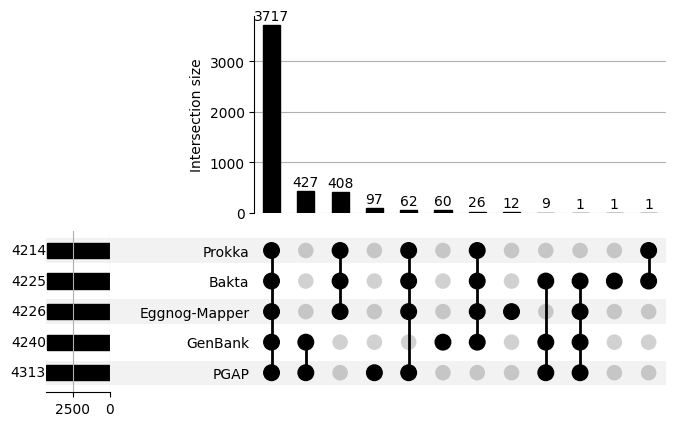

In [9]:
indicators = pd.crosstab(all_gffs["orf_id"], all_gffs["Source"]).astype(bool)
from upsetplot import UpSet, from_indicators
df_upset = from_indicators(indicators)
upset = UpSet(df_upset, subset_size='count', show_counts='%d',
              sort_by="cardinality", sort_categories_by='cardinality')
upset.plot()

### 3. Annotation analysis
Now we proceed to checking if the functional annotation differs.

In [10]:
from Bio import SeqIO

In [11]:
!wget https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/009/045/GCF_000009045.1_ASM904v1/GCF_000009045.1_ASM904v1_genomic.gbff.gz
!gunzip GCF_000009045.1_ASM904v1_genomic.gbff.gz
!mv GCF_000009045.1_ASM904v1_genomic.gbff bacillus_genbank.gbff


--2025-11-26 16:37:16--  https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/009/045/GCF_000009045.1_ASM904v1/GCF_000009045.1_ASM904v1_genomic.gbff.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.10, 130.14.250.11, 130.14.250.13, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3391532 (3.2M) [application/x-gzip]
Saving to: ‘GCF_000009045.1_ASM904v1_genomic.gbff.gz’

GCF_000009045.1_ASM 100%[===================>]   3.23M  3.25MB/s    in 1.0s    

2025-11-26 16:37:18 (3.25 MB/s) - ‘GCF_000009045.1_ASM904v1_genomic.gbff.gz’ saved [3391532/3391532]



In [12]:
def compare_annotations(df1, df2, column_to_compare, df1_name="DF1", df2_name="DF2"):
    """
    Compare two DataFrames based on location and a specified column.

    Args:
        df1 (pd.DataFrame): First DataFrame (e.g., Prokka annotations).
        df2 (pd.DataFrame): Second DataFrame (e.g., GenBank annotations).
        column_to_compare (str): Column name to compare (e.g., "uniprotkb").
        df1_name (str): Name of the first DataFrame (e.g., "Prokka").
        df2_name (str): Name of the second DataFrame (e.g., "GenBank").
        output_csv (str): Path to save the comparison report.

    Returns:
        pd.DataFrame: Merged DataFrame with comparison results.
        dict: Summary statistics.
    """
    # Merge the two DataFrames on location
    merged_df = pd.merge(df1, df2, on="location", suffixes=(f"_{df1_name.lower()}", f"_{df2_name.lower()}"))

    # Check agreement on the specified column
    merged_df[f"{column_to_compare}_agree"] = (
        merged_df[f"{column_to_compare}_{df1_name.lower()}"] == merged_df[f"{column_to_compare}_{df2_name.lower()}"]
    )

    # Check hypothetical proteins
    merged_df[f"is_hypothetical_{df1_name.lower()}"] = merged_df[f"product_{df1_name.lower()}"] == "hypothetical protein"
    merged_df[f"is_hypothetical_{df2_name.lower()}"] = merged_df[f"product_{df2_name.lower()}"] == "hypothetical protein"

    # Print statistics
    print(f"Number of CDSs in the merged DataFrame: {len(merged_df)}")
    print(f"Number of identical {column_to_compare} matches: {merged_df[f'{column_to_compare}_agree'].sum()}")
    print(f"Number of different {column_to_compare} matches: {(~merged_df[f'{column_to_compare}_agree']).sum()}. "
      f"Of those, {merged_df[f'{column_to_compare}_{df1_name.lower()}'].isna().sum()} are missing in {df1_name} "
      f"and {merged_df[f'{column_to_compare}_{df2_name.lower()}'].isna().sum()} are missing in {df2_name}.")
    print(f"Number of hypothetical proteins in both datasets: {((merged_df[f'is_hypothetical_{df1_name.lower()}']) & (merged_df[f'is_hypothetical_{df2_name.lower()}'])).sum()}")
    print(f"Number of hypothetical proteins only in {df1_name}: {((merged_df[f'is_hypothetical_{df1_name.lower()}']) & (~merged_df[f'is_hypothetical_{df2_name.lower()}'])).sum()}")
    print(f"Number of hypothetical proteins only in {df2_name}: {((~merged_df[f'is_hypothetical_{df1_name.lower()}']) & (merged_df[f'is_hypothetical_{df2_name.lower()}'])).sum()}")

    return merged_df


In [13]:
genbank_gbff = "bacillus_genbank.gbff"
prokka_gbk = "../results/prokka/bacillus_prokka/bacillus.gbk"
pgap_gbk = "../results/pgap/bacillus_pgap/annot.gbk"
bakta_gbk = "../results/bakta/bacillus_bakta/bacillus.gbff"

### PROKA X GENBANK

In [14]:
cds_data = []
for record in SeqIO.parse(genbank_gbff, "genbank"):
    for feature in record.features:
        if feature.type == "CDS":
            location = str(feature.location).split('(')[0]
            product = feature.qualifiers.get("product", ["hypothetical protein"])[0]
            uniprotkb = None
            db_xref = feature.qualifiers.get("db_xref", [])
            for ref in db_xref:
                if ref.startswith("UniProtKB"):
                    uniprotkb = ref.split(":")[1]
            cds_data.append({"location": location, "product": product, "uniprotkb": uniprotkb})
genbank = pd.DataFrame(cds_data)
genbank


,location,product,uniprotkb
0,[409:1750],chromosomal replication initiator informationa...,P05648
1,[1938:3075],DNA polymerase III (beta subunit),P05649
2,[3205:3421],RNA binding protein involved in ribosome matur...,P05650
3,[3436:4549],"RecA filament-DNA complex stabilisation, ssDNA...",P05651
4,[4566:4812],regulator of extracellular matrix formation,P37525
...,...,...,...
4232,[4211509:4212889],tRNA modification GTPase and tRNA-U34 5-formyl...,P25811
4233,[4213199:4213826],SpoIIIJ-associated RNA/ssDNA-binding protein,Q01620
4234,[4213822:4214608],Sec-independent factor for membrane protein in...,Q01625
4235,[4214752:4215103],protein component of ribonuclease P (RNase P) ...,P25814


In [15]:
cds_data = []
for record in SeqIO.parse(prokka_gbk, "genbank"):
    for feature in record.features:
        if feature.type == "CDS":
            location = str(feature.location).split('(')[0]
            product = feature.qualifiers.get("product", ["hypothetical protein"])[0]
            inference = feature.qualifiers.get("inference", [None])
            uniprotkb = None
            if inference:
                for inf in inference:
                    if "UniProtKB" in inf:
                        uniprotkb = inf.split(":")[2]
            cds_data.append({"location": location, "product": product, "uniprotkb": uniprotkb})
prokka = pd.DataFrame(cds_data)
prokka

,location,product,uniprotkb
0,[409:1750],Chromosomal replication initiator protein DnaA,P05648
1,[1938:3075],Beta sliding clamp,P05649
2,[3205:3421],hypothetical protein,None
3,[3436:4549],DNA replication and repair protein RecF,Q8RDL3
4,[4566:4812],hypothetical protein,None
...,...,...,...
4209,[4209602:4211489],tRNA uridine 5-carboxymethylaminomethyl modifi...,P64230
4210,[4211509:4212889],tRNA modification GTPase MnmE,Q8YN91
4211,[4213199:4213826],hypothetical protein,None
4212,[4213822:4214602],Membrane protein insertase MisCA,Q01625


In [16]:
prokka_genbank = compare_annotations(prokka, genbank, "uniprotkb", df1_name="Prokka", df2_name="GenBank")

Number of CDSs in the merged DataFrame: 3743
Number of identical uniprotkb matches: 1666
Number of different uniprotkb matches: 2077. Of those, 1190 are missing in Prokka and 13 are missing in GenBank.
Number of hypothetical proteins in both datasets: 348
Number of hypothetical proteins only in Prokka: 800
Number of hypothetical proteins only in GenBank: 40


Here we can see the unmatched proteins. 887 of them. Many of the Prokka's IDs are matched to very similar proteins from other bacteria. Some have very different descriptions

In [17]:
prokka_genbank[~prokka_genbank["uniprotkb_agree"]].dropna()

,location,product_prokka,uniprotkb_prokka,product_genbank,uniprotkb_genbank,uniprotkb_agree,is_hypothetical_prokka,is_hypothetical_genbank
3,[3436:4549],DNA replication and repair protein RecF,Q8RDL3,"RecA filament-DNA complex stabilisation, ssDNA...",P05651,False,False,False
11,[20879:22157],Serine--tRNA ligase,O66647,seryl-tRNA synthetase,P37464,False,False,False
15,[25220:25766],Vibriobactin-specific isochorismatase,P0C6D3,putative amidase (isochorismatase family),P37532,False,False,False
18,[28528:28852],Nucleoid-associated protein,A3DHB8,nucleoid associated protein,P24281,False,False,False
19,[28866:29463],Recombination protein RecR,Q8RDI4,recA filament-DNA complex stabilisation factor,P24277,False,False,False
...,...,...,...,...,...,...,...,...
3722,[4194388:4195744],Inner membrane metabolite transport protein YdjE,P38055,putative transporter,P37514,False,False,False
3723,[4195777:4196332],Maltose O-acetyltransferase,P77791,maltose O-acetyltransferase,P37515,False,False,False
3731,[4201069:4203073],putative dimethyl sulfoxide reductase chain YnfF,P77783,putative oxidoreductase (molybdoenzyme),P37519,False,False,False
3739,[4209602:4211489],tRNA uridine 5-carboxymethylaminomethyl modifi...,P64230,tRNA uridine 5-carboxymethylaminomethyl modifi...,P25812,False,False,False


few proteins are considered non hypothetical in Prokka and hypothetical in GenBank (40). Most are putatives.

In [18]:
# proteins that are hypothetical in GenBank but not in Prokka
prokka_genbank[(~prokka_genbank["is_hypothetical_prokka"]) & (prokka_genbank["is_hypothetical_genbank"])]

,location,product_prokka,uniprotkb_prokka,product_genbank,uniprotkb_genbank,uniprotkb_agree,is_hypothetical_prokka,is_hypothetical_genbank
40,[52762:53023],Protein Veg,P37466,hypothetical protein,P37466,True,False,True
299,[349995:350853],Putative two-component membrane permease compl...,Q8DUY4,hypothetical protein,P94394,False,False,True
442,[528128:528581],Protein SprT-like protein,None,hypothetical protein,P96628,False,False,True
631,[754479:754923],putative protein YesE,O31511,hypothetical protein,O31511,True,False,True
775,[926428:926743],putative protein YfhH,O31576,hypothetical protein,O31576,True,False,True
876,[1055142:1056216],putative protein YhaZ,O07541,hypothetical protein,O07541,True,False,True
983,[1182447:1183032],Sporulation delaying protein C,O34344,hypothetical protein,O06748,False,False,True
1077,[1283168:1283336],putative protein YjfB,O34438,hypothetical protein,O34438,True,False,True
1079,[1284869:1285445],putative protein YjgB,O34960,hypothetical protein,O34960,True,False,True
1092,[1298611:1299034],putative protein YjlC,O34633,hypothetical protein,O34633,True,False,True


In contrast, 800 CDSs were considered hypothetical in prokka, that are not in GenBank. Some are matched to the ID, but most are missing from Prokka

In [19]:
prokka_genbank[(~prokka_genbank["is_hypothetical_genbank"]) & (prokka_genbank["is_hypothetical_prokka"])]

,location,product_prokka,uniprotkb_prokka,product_genbank,uniprotkb_genbank,uniprotkb_agree,is_hypothetical_prokka,is_hypothetical_genbank
2,[3205:3421],hypothetical protein,None,RNA binding protein involved in ribosome matur...,P05650,False,True,False
4,[4566:4812],hypothetical protein,None,regulator of extracellular matrix formation,P37525,False,True,False
17,[26813:28505],hypothetical protein,None,DNA polymerase III subunit tau subunit,P09122,False,True,False
23,[35844:36459],hypothetical protein,None,putative phosphatase,P37467,False,True,False
29,[40664:41654],hypothetical protein,None,DNA polymerase III clamp loader delta' subunit,P37540,False,True,False
...,...,...,...,...,...,...,...,...
3724,[4196349:4196730],hypothetical protein,None,putative C-S lyase,P37516,False,True,False
3732,[4203123:4203330],hypothetical protein,None,putative nucleic acid binding protein,C0H3V8,False,True,False
3733,[4204899:4205517],hypothetical protein,None,spore-specific protease,P37521,False,True,False
3736,[4207405:4207846],hypothetical protein,None,putative antibiotic immunity protein,P37523,False,True,False


However, a lot of them are also putative, hypothetical or unknown. Specifically, 203 proteins in genbank dont contain these terms and are hypothetical in Prokka.

In [20]:
prokka_genbank[(~prokka_genbank["is_hypothetical_genbank"]) & (prokka_genbank["is_hypothetical_prokka"])]["product_genbank"].str.contains("unknown|putative|hypothetical", case=False).sum()

np.int64(597)

### BAKTA X GENBANK

In [21]:
cds_data = []
for record in SeqIO.parse(bakta_gbk, "genbank"):
    for feature in record.features:
        if feature.type == "CDS":
            location = str(feature.location).split('(')[0]
            product = feature.qualifiers.get("product", ["hypothetical protein"])[0]
            uniprotkb = None
            for note in feature.qualifiers.get("note", []):
                if "UniRef:UniRef100" in note:
                    uniprotkb = note.split("UniRef:UniRef100_")[1]
                elif "UniRef:UniRef90" in note:
                    uniprotkb = note.split("UniRef:UniRef90_")[1]
                elif "UniRef:UniRef50" in note:
                    uniprotkb = note.split("UniRef:UniRef50_")[1]
            cds_data.append({"location": location, "product": product, "uniprotkb": uniprotkb})
            
bakta = pd.DataFrame(cds_data)
bakta

,location,product,uniprotkb
0,[409:1750],chromosomal replication initiator protein DnaA,P05648
1,[1938:3075],DNA polymerase III subunit beta,P05649
2,[3205:3421],ribosome maturation protein RlbA,P05650
3,[3436:4549],DNA replication/repair protein RecF,P05651
4,[4566:4812],extracellular matrix regulator RemB,P37525
...,...,...,...
4220,[4209602:4211489],tRNA uridine-5-carboxymethylaminomethyl(34) sy...,P25812
4221,[4211509:4212889],tRNA uridine-5-carboxymethylaminomethyl(34) sy...,P25811
4222,[4213199:4213826],RNA-binding cell elongation regulator Jag/EloR,Q01620
4223,[4213822:4214602],YidC family membrane integrase SpoIIIJ,Q01625


In [22]:
bakta_genbank = compare_annotations(bakta, genbank, "uniprotkb", df1_name="Bakta", df2_name="GenBank")

Number of CDSs in the merged DataFrame: 3753
Number of identical uniprotkb matches: 3716
Number of different uniprotkb matches: 37. Of those, 0 are missing in Bakta and 14 are missing in GenBank.
Number of hypothetical proteins in both datasets: 7
Number of hypothetical proteins only in Bakta: 3
Number of hypothetical proteins only in GenBank: 381


In [23]:
bakta_genbank[~bakta_genbank["uniprotkb_agree"]].dropna()

,location,product_bakta,uniprotkb_bakta,product_genbank,uniprotkb_genbank,uniprotkb_agree,is_hypothetical_bakta,is_hypothetical_genbank
18,[28528:28852],YbaB/EbfC family nucleoid-associated protein,Q65PK0,nucleoid associated protein,P24281,False,False,False
412,[495739:496561],Manganese catalase,A0A7R7ZDZ6,putative manganese-containing catalase,P80878,False,False,False
787,[937899:938154],"Small, acid-soluble spore protein gamma-type",P84585,small acid-soluble spore protein (gamma-type S...,P07784,False,False,False
1559,[1864690:1865044],multidrug efflux SMR transporter subunit EbrB,P0CW83,small toxic metabolite efflux transporter subunit,P0CW82,False,False,False
1586,[1890511:1891666],Xylose repressor,P16557,transcriptional regulator,P94490,False,False,False
1592,[1900079:1900514],dUTP diphosphatase DutA,O34919,deoxyuridine 5'-triphosphate pyrophosphatase (...,O31801,False,False,False
1679,[2034744:2035782],Pectin lyase,P94449,endo-pectin lyase,O34819,False,False,False
1701,[2057800:2058460],Abasic site processing protein YobE,O31916,putative SOS response associated phage protein...,O34915,False,False,False
1829,[2171400:2172732],Orphan methyltransferase M-SPBetaI,P09389,DNA (cytosine-5-)-methyltransferase; phage SPbeta,P68585,False,False,False
1836,[2175595:2179513],putative DNA polymerase YorL,O64146,DNA polymerase with 3'-5' exonuclease activity...,O31902,False,False,False


In [24]:
bakta_genbank[(~bakta_genbank["is_hypothetical_bakta"]) & (bakta_genbank["is_hypothetical_genbank"])]

,location,product_bakta,uniprotkb_bakta,product_genbank,uniprotkb_genbank,uniprotkb_agree,is_hypothetical_bakta,is_hypothetical_genbank
6,[14846:15794],putative protein YaaC,P37526,hypothetical protein,P37526,True,False,True
20,[29480:29705],putative protein YaaL,P37533,hypothetical protein,P37533,True,False,True
28,[40212:40653],putative protein YaaR,P37539,hypothetical protein,P37539,True,False,True
40,[52762:53023],biofilm formation stimulator Veg,P37466,hypothetical protein,P37466,True,False,True
61,[73105:73843],putative protein YabS,P37561,hypothetical protein,P37561,True,False,True
...,...,...,...,...,...,...,...,...
3713,[4177755:4178145],putative protein YybH,P37496,hypothetical protein,P37496,True,False,True
3714,[4178290:4179130],putative protein YybG,P37497,hypothetical protein,P37497,True,False,True
3724,[4186091:4186448],putative protein YyaQ,P37507,hypothetical protein,P37507,True,False,True
3728,[4189405:4189645],putative protein YyaO,P37509,hypothetical protein,P37509,True,False,True


### PGAP X GENBANK

In [25]:
cds_data = []
for record in SeqIO.parse(pgap_gbk, "genbank"):
    for feature in record.features:
        if feature.type == "CDS":
            location = str(feature.location).split('(')[0]
            product = feature.qualifiers.get("product", ["hypothetical protein"])[0]
            refseq_code = None
            inferences = feature.qualifiers.get("inference", [])
            for inference in inferences:
                if "RefSeq" in inference:
                    refseq_code = inference.split(":")[3]
                elif "motif" in inference:
                    refseq_code = inference.split(":")[3]
            cds_data.append({"location": location, "product": product, "refseq_code": refseq_code})
pgap = pd.DataFrame(cds_data)
pgap

,location,product,refseq_code
0,[409:1750],chromosomal replication initiator protein DnaA,NP_387882.1
1,[1938:3075],DNA polymerase III subunit beta,NP_387883.1
2,[3205:3421],ribosome maturation protein RlbA,NP_387884.1
3,[3436:4549],DNA replication/repair protein RecF,NP_387885.1
4,[4566:4812],extracellular matrix regulator RemB,NP_387886.2
...,...,...,...
4307,[4211509:4212889],tRNA uridine-5-carboxymethylaminomethyl(34) sy...,NP_391982.1
4308,[4213199:4213826],RNA-binding cell elongation regulator Jag/EloR,NP_391983.1
4309,[4213822:4214608],YidC family membrane integrase SpoIIIJ,NP_391984.1
4310,[4214752:4215103],ribonuclease P protein component,NP_391985.1


In [26]:
cds_data = []
for record in SeqIO.parse(genbank_gbff, "genbank"):
    for feature in record.features:
        if feature.type == "CDS":
            location = str(feature.location).split('(')[0]
            product = feature.qualifiers.get("product", ["hypothetical protein"])[0]
            refseq_code = feature.qualifiers.get("protein_id", [None])[0]
            cds_data.append({"location": location, "product": product, "refseq_code": refseq_code})
genbank = pd.DataFrame(cds_data)
genbank

,location,product,refseq_code
0,[409:1750],chromosomal replication initiator informationa...,NP_387882.1
1,[1938:3075],DNA polymerase III (beta subunit),NP_387883.1
2,[3205:3421],RNA binding protein involved in ribosome matur...,NP_387884.1
3,[3436:4549],"RecA filament-DNA complex stabilisation, ssDNA...",NP_387885.1
4,[4566:4812],regulator of extracellular matrix formation,NP_387886.2
...,...,...,...
4232,[4211509:4212889],tRNA modification GTPase and tRNA-U34 5-formyl...,NP_391982.1
4233,[4213199:4213826],SpoIIIJ-associated RNA/ssDNA-binding protein,NP_391983.1
4234,[4213822:4214608],Sec-independent factor for membrane protein in...,NP_391984.1
4235,[4214752:4215103],protein component of ribonuclease P (RNase P) ...,NP_391985.1


In [27]:
pgap_genbank = compare_annotations(pgap, genbank, "refseq_code", df1_name="PGAP", df2_name="GenBank")

Number of CDSs in the merged DataFrame: 4150
Number of identical refseq_code matches: 4110
Number of different refseq_code matches: 40. Of those, 0 are missing in PGAP and 0 are missing in GenBank.
Number of hypothetical proteins in both datasets: 160
Number of hypothetical proteins only in PGAP: 223
Number of hypothetical proteins only in GenBank: 311


In [28]:
pgap_genbank

,location,product_pgap,refseq_code_pgap,product_genbank,refseq_code_genbank,refseq_code_agree,is_hypothetical_pgap,is_hypothetical_genbank
0,[409:1750],chromosomal replication initiator protein DnaA,NP_387882.1,chromosomal replication initiator informationa...,NP_387882.1,True,False,False
1,[1938:3075],DNA polymerase III subunit beta,NP_387883.1,DNA polymerase III (beta subunit),NP_387883.1,True,False,False
2,[3205:3421],ribosome maturation protein RlbA,NP_387884.1,RNA binding protein involved in ribosome matur...,NP_387884.1,True,False,False
3,[3436:4549],DNA replication/repair protein RecF,NP_387885.1,"RecA filament-DNA complex stabilisation, ssDNA...",NP_387885.1,True,False,False
4,[4566:4812],extracellular matrix regulator RemB,NP_387886.2,regulator of extracellular matrix formation,NP_387886.2,True,False,False
...,...,...,...,...,...,...,...,...
4145,[4211509:4212889],tRNA uridine-5-carboxymethylaminomethyl(34) sy...,NP_391982.1,tRNA modification GTPase and tRNA-U34 5-formyl...,NP_391982.1,True,False,False
4146,[4213199:4213826],RNA-binding cell elongation regulator Jag/EloR,NP_391983.1,SpoIIIJ-associated RNA/ssDNA-binding protein,NP_391983.1,True,False,False
4147,[4213822:4214608],YidC family membrane integrase SpoIIIJ,NP_391984.1,Sec-independent factor for membrane protein in...,NP_391984.1,True,False,False
4148,[4214752:4215103],ribonuclease P protein component,NP_391985.1,protein component of ribonuclease P (RNase P) ...,NP_391985.1,True,False,False


In [29]:
pgap_genbank[~pgap_genbank["refseq_code_agree"]].dropna()

,location,product_pgap,refseq_code_pgap,product_genbank,refseq_code_genbank,refseq_code_agree,is_hypothetical_pgap,is_hypothetical_genbank
48,[55865:56159],septation regulator SpoVG,WP_000454041.1,regulator required for spore cortex synthesis ...,NP_387930.1,False,False,False
110,[130159:130630],30S ribosomal protein S7,WP_013054923.1,ribosomal protein S7 (BS7),NP_387992.2,False,False,False
111,[130683:132762],elongation factor G,WP_000090364.1,elongation factor G,NP_387993.2,False,False,False
114,[135363:135672],30S ribosomal protein S10,WP_001118669.1,ribosomal protein S10 (BS13); transcription an...,NP_387996.1,False,False,False
119,[138201:138480],30S ribosomal protein S19,WP_000124454.1,ribosomal protein S19 (BS19),NP_388001.1,False,False,False
120,[138496:138838],50S ribosomal protein L22,WP_001148024.1,ribosomal protein L22 (BL17),NP_388002.1,False,False,False
122,[139499:139934],50S ribosomal protein L16,WP_003225801.1,ribosomal protein L16,NP_388004.1,False,False,False
124,[140146:140410],30S ribosomal protein S17,WP_011983253.1,ribosomal protein S17 (BS16),NP_388006.1,False,False,False
125,[140450:140819],50S ribosomal protein L14,WP_012727667.1,ribosomal protein L14,NP_388007.1,False,False,False
128,[141756:141942],30S ribosomal protein S14,WP_011245027.1,ribosomal protein S14,NP_388010.1,False,False,False


a lot bring some kind of annotation, but on GenBank, they are hypothetical. Must investigate with evidence level!

In [30]:
pgap_genbank[(~pgap_genbank["is_hypothetical_pgap"]) & (pgap_genbank["is_hypothetical_genbank"])]

,location,product_pgap,refseq_code_pgap,product_genbank,refseq_code_genbank,refseq_code_agree,is_hypothetical_pgap,is_hypothetical_genbank
7,[14846:15794],YaaC family protein,NP_387889.1,hypothetical protein,NP_387889.1,True,False,True
21,[29480:29705],YaaL family protein,NP_387903.1,hypothetical protein,NP_387903.1,True,False,True
29,[40212:40653],YaaR family protein,NP_387911.1,hypothetical protein,NP_387911.1,True,False,True
43,[52762:53023],biofilm formation stimulator Veg,NP_387925.1,hypothetical protein,NP_387925.1,True,False,True
64,[73105:73843],VWA domain-containing protein,NP_387946.1,hypothetical protein,NP_387946.1,True,False,True
...,...,...,...,...,...,...,...,...
4106,[4177755:4178145],YybH family protein,NP_391944.1,hypothetical protein,NP_391944.1,True,False,True
4107,[4178290:4179130],pentapeptide repeat-containing protein,NP_391945.1,hypothetical protein,NP_391945.1,True,False,True
4117,[4186091:4186448],MmcQ/YjbR family DNA-binding protein,NP_391955.1,hypothetical protein,NP_391955.1,True,False,True
4121,[4189405:4189645],DUF255 domain-containing protein,NP_391959.1,hypothetical protein,NP_391959.1,True,False,True
